Data sources: [Statistics Canada](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1310083701) <i>("download entire table as CSV")</i><br>
[List of Canadian provinces and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_Canadian_provinces_and_territories_by_life_expectancy) / [Продолжительность жизни в провинциях и территориях Канады](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_провинциях_и_территориях_Канады)

In [2]:
import pandas as pd
import math
import re
from collections import namedtuple
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import sys
sys.path.append("..")
import mal_moduls_private.mal_total as mal

In [3]:
pd.options.display.min_rows=8
# pd.options.display.max_rows=110

In [4]:
LANGS = ['en']  # languages of the charts (this setting doesn't have influence on tables)  #['en', 'ru', 'nolang']
YEAR = 2019
EXPLORE_PERIOD = True  # Change this value to 'False' to speed up work of the script, if the exploration is not required
WRITE_TABLE = False
DESTINATION_CHART = 'show'  # to where table code should be placed: 'file', 'show'

REGION_1 = 'Ontario'
REGION_2 = 'Quebec'
REGION_3 = 'British Columbia'

<br>

In [6]:
# For overview, explore probability of dying at certain age during a some period
def explore_change_of_probability_for_given_age(age_to_explore: str, region_to_explore='Canada'):
    df = pd.read_csv('data/Canada-1year-2024.zip', compression='zip',
                 usecols = ['REF_DATE', 'GEO', 'Age group', 'Sex', 'Element', 'VALUE'])

    df= df.loc[(df['GEO'] == region_to_explore) &
               (df['Age group'] == age_to_explore) &
               (df['Element'] == 'Death probability between age x and x+1 (qx)')]

    df = df.drop(columns=['GEO', 'Age group', 'Element']) \
           .rename(columns={'REF_DATE': 'year',
                            'Sex': 'sex',
                            'VALUE': 'value'})

    df['value'] = df['value'] * 100

    df = pd.pivot_table(df, values='value', index='year', columns='sex')

    df.rename(columns={'Both sexes':'total', 'Males':'male', 'Females':'female'}, inplace=True)
    df = df[['male', 'total', 'female']]
    df['mΔf'] = df['male'] - df['female']
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.index.name = ''
    df.columns.name = ''

    return df


age_to_explore = '109 years'
df_to_explore = pd.DataFrame()
if EXPLORE_PERIOD:
    df_to_explore = explore_change_of_probability_for_given_age(age_to_explore)
df_to_explore.loc[2000:]

,male,total,female,mΔf,ratio_mf
,,,,,
2000,51.251,48.667,50.321,0.930,1.02
2001,52.315,49.819,50.762,1.553,1.03
2002,53.102,50.119,50.758,2.344,1.05
2003,52.639,49.969,50.800,1.839,1.04
2004,52.609,50.195,51.040,1.569,1.03
2005,53.076,50.304,50.965,2.111,1.04
2006,52.627,49.636,50.274,2.353,1.05
2007,52.550,49.876,50.582,1.968,1.04
2008,52.571,49.511,50.162,2.409,1.05


<br>

<h4>Basic calculations</h4>

In [8]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'nolang_name', 'color', 'style', 'width', 'alpha'])

In [9]:
# load data
df = pd.read_csv('data/Canada-1year-2024.zip', compression='zip',
                 usecols = ['REF_DATE', 'GEO', 'Age group', 'Sex', 'Element', 'VALUE'])

df= df.loc[(df['REF_DATE'] == YEAR) & (df['Element'] == 'Death probability between age x and x+1 (qx)')]

df.head(2)

,REF_DATE,GEO,Age group,Sex,Element,VALUE
1168832,2019,Canada,0 years,Both sexes,Death probability between age x and x+1 (qx),0.00438
1168841,2019,Canada,0 years,Males,Death probability between age x and x+1 (qx),0.00488


In [10]:
# filter dataFrame
df = df.drop(columns=['REF_DATE', 'Element']) \
       .rename(columns={'GEO': 'region',
                        'Age group': 'age',
                        'Sex': 'sex',
                        'VALUE': 'value'})

df['age'] = df['age'].replace({'110 years and over' : '110', '1 year' : '1'}) \
                     .map(lambda st: st.replace(' years', ''))  \
                     .astype(int)

df['value'] = df['value'] * 100

df

,region,age,sex,value
1168832,Canada,0,Both sexes,0.438
1168841,Canada,0,Males,0.488
1168850,Canada,0,Females,0.386
1168859,Canada,1,Both sexes,0.024
...,...,...,...,...
1198766,British Columbia,109,Females,50.681
1198775,British Columbia,110,Both sexes,100.000
1198784,British Columbia,110,Males,100.000
1198793,British Columbia,110,Females,100.000


In [11]:
# check types of values in columns, just in case
df.dtypes

region     object
age         int32
sex        object
value     float64
dtype: object

<br>

In [13]:
# df.head(4)

In [14]:
def get_data_for_single_region(df, region, suffix_for_columns=''):
    df = df.loc[df['region'] == region] \
           .drop(columns=['region'])

    df = pd.pivot_table(df, values='value', index='age', columns='sex')

    df.rename(columns={'Both sexes':'total', 'Males':'male', 'Females':'female'}, inplace=True)
    df = df[['male', 'total', 'female']]
    df['mΔf'] = df['male'] - df['female']
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]
    
    return df


df = pd.concat([
        get_data_for_single_region(df, 'Canada'),
        get_data_for_single_region(df, REGION_1, '_r1'),
        get_data_for_single_region(df, REGION_2, '_r2'),
        get_data_for_single_region(df, REGION_3, '_r3')], axis='columns')
df.index.name = ''

# drop values for 110, since this record doesn't have sense
df.drop(index=110, inplace=True)

df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109]]

,male,total,female,mΔf,ratio_mf,male_r1,total_r1,female_r1,mΔf_r1,ratio_mf_r1,male_r2,total_r2,female_r2,mΔf_r2,ratio_mf_r2,male_r3,total_r3,female_r3,mΔf_r3,ratio_mf_r3
,,,,,,,,,,,,,,,,,,,,
0,0.488,0.438,0.386,0.102,1.26,0.476,0.447,0.417,0.059,1.14,0.490,0.406,0.318,0.172,1.54,0.367,0.330,0.290,0.077,1.27
1,0.026,0.024,0.022,0.004,1.18,0.022,0.020,0.019,0.003,1.16,0.030,0.022,0.015,0.015,2.00,0.015,0.021,0.019,-0.004,0.79
5,0.009,0.009,0.009,0.000,1.00,0.008,0.009,0.009,-0.001,0.89,0.006,0.007,0.007,-0.001,0.86,0.010,0.007,0.008,0.002,1.25
10,0.008,0.007,0.007,0.001,1.14,0.008,0.007,0.005,0.003,1.60,0.006,0.005,0.003,0.003,2.00,0.007,0.006,0.006,0.001,1.17
20,0.065,0.048,0.029,0.036,2.24,0.055,0.042,0.026,0.029,2.12,0.054,0.039,0.020,0.034,2.70,0.068,0.049,0.025,0.043,2.72
30,0.101,0.075,0.047,0.054,2.15,0.095,0.071,0.046,0.049,2.07,0.060,0.044,0.027,0.033,2.22,0.122,0.090,0.055,0.067,2.22
40,0.141,0.111,0.080,0.061,1.76,0.138,0.108,0.078,0.060,1.77,0.093,0.075,0.057,0.036,1.63,0.158,0.124,0.089,0.069,1.78
50,0.287,0.235,0.183,0.104,1.57,0.282,0.226,0.172,0.110,1.64,0.241,0.205,0.167,0.074,1.44,0.308,0.242,0.179,0.129,1.72
60,0.684,0.557,0.431,0.253,1.59,0.673,0.538,0.408,0.265,1.65,0.622,0.523,0.419,0.203,1.48,0.663,0.525,0.392,0.271,1.69


In [15]:
# alternative look at the result
df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109], ['male', 'male_r1', 'male_r2', 'male_r3', 'female', 'female_r1', 'female_r2', 'female_r3']]

,male,male_r1,male_r2,male_r3,female,female_r1,female_r2,female_r3
,,,,,,,,
0,0.488,0.476,0.490,0.367,0.386,0.417,0.318,0.290
1,0.026,0.022,0.030,0.015,0.022,0.019,0.015,0.019
5,0.009,0.008,0.006,0.010,0.009,0.009,0.007,0.008
10,0.008,0.008,0.006,0.007,0.007,0.005,0.003,0.006
20,0.065,0.055,0.054,0.068,0.029,0.026,0.020,0.025
30,0.101,0.095,0.060,0.122,0.047,0.046,0.027,0.055
40,0.141,0.138,0.093,0.158,0.080,0.078,0.057,0.089
50,0.287,0.282,0.241,0.308,0.183,0.172,0.167,0.179
60,0.684,0.673,0.622,0.663,0.431,0.408,0.419,0.392


<br>

In [17]:
# explore the the "plateau" manually, if we want
# df.loc[16:40]

In [18]:
# just for fun, calculate average values during the "plateau" for the country and the separate regions
plateau_years = slice(21, 30)

dfe = pd.concat([
    df.loc[plateau_years, ['male', 'total', 'female']].mean(),
    df.loc[plateau_years, ['male_r1', 'total_r1', 'female_r1']].mean().rename(index={'male_r1':'male', 'total_r1':'total', 'female_r1':'female'}),
    df.loc[plateau_years, ['male_r2', 'total_r2', 'female_r2']].mean().rename(index={'male_r2':'male', 'total_r2':'total', 'female_r2':'female'}),
    df.loc[plateau_years, ['male_r3', 'total_r3', 'female_r3']].mean().rename(index={'male_r3':'male', 'total_r3':'total', 'female_r3':'female'})
], axis='columns').T
dfe['ratio_mf'] = (dfe['male'] / dfe['female']).round(2)
dfe.index = ['Canada', REGION_1, REGION_2, REGION_3]
dfe.round(3)

,male,total,female,ratio_mf
Canada,0.087,0.063,0.038,2.32
Ontario,0.078,0.057,0.034,2.26
Quebec,0.059,0.041,0.022,2.69
British Columbia,0.103,0.073,0.041,2.52


In [19]:
# calculate average life expectancy if during the whole life of people the mortality rate will the the same as at the "plateau"
def calculate_average_LE_if_mortality_as_at_plateau(mortality_in_perc):
    mortality = mortality_in_perc / 100
    average_le = 1 / mortality
    return int(average_le)

dfe['le_ageless_male'] = dfe['male'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_total'] = dfe['total'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_female'] = dfe['female'].map(calculate_average_LE_if_mortality_as_at_plateau)
# dfe['ratio_ageless'] = (dfe['le_ageless_female'] / dfe['le_ageless_male']).round(2)  # values the same as in the columns 'ratio_mf'
dfe.round(3)

,male,total,female,ratio_mf,le_ageless_male,le_ageless_total,le_ageless_female
Canada,0.087,0.063,0.038,2.32,1149,1584,2666
Ontario,0.078,0.057,0.034,2.26,1283,1751,2898
Quebec,0.059,0.041,0.022,2.69,1694,2415,4566
British Columbia,0.103,0.073,0.041,2.52,970,1369,2450


<br>

In [21]:
def create_table(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    prec = 3
    for age in [1] + list(range(5, 106, 5)) + [109]:
        ser = df.loc[age]
        st += '\n' + '|-\n' + \
            f'|style="padding-right:3ex;"| {age} ' + \
            f'||style="color:blue;padding-right:1ex;"| {transform_value(ser.loc['male'], prec=prec)} ' + \
            f'||style="padding-right:1ex;"| {transform_value(ser.loc['total'], prec=prec)} ' + \
            f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['female'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {transform_value(ser.loc['mΔf'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf']:0.2f} ' + \
            f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['male_r1'], prec=prec)} ' + \
            f'||style="padding-right:1ex;"| {transform_value(ser.loc['total_r1'], prec=prec)} ' + \
            f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['female_r1'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {transform_value(ser.loc['mΔf_r1'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_r1']:0.2f} ' + \
            f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['male_r2'], prec=prec)} ' + \
            f'||style="padding-right:1ex;\"| {transform_value(ser.loc['total_r2'], prec=prec)} ' + \
            f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['female_r2'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {transform_value(ser.loc['mΔf_r2'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_r2']:0.2f} ' + \
            f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['male_r3'], prec=prec)} ' + \
            f'||style="padding-right:1ex;\"| {transform_value(ser.loc['total_r3'], prec=prec)} ' + \
            f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['female_r3'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {transform_value(ser.loc['mΔf_r3'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_r3']:0.2f}'

    # fix microbugs that can happened due to nuances of calculations and rounding
    st = st.replace('color:darkgray;padding-right:3ex;"| -0.0 ', 'color:darkgray;padding-right:3ex;"| 0.0 ')

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'
    return st
        

if WRITE_TABLE:
    table_code = create_table(df, file_header='Probability_of_dying_extended -en.txt', lang='en')
    with open(f"output/Table code for probability of dying extended -{YEAR} -en.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

    # table_code = create_table(df, file_header='Probability_of_dying_extended -ru.txt', lang='ru')
    # with open('output/Table code for probability surviving extended -ru.txt', 'w', encoding="utf-8") as fh:
    #     fh.write(table_code)

<br>
<br>

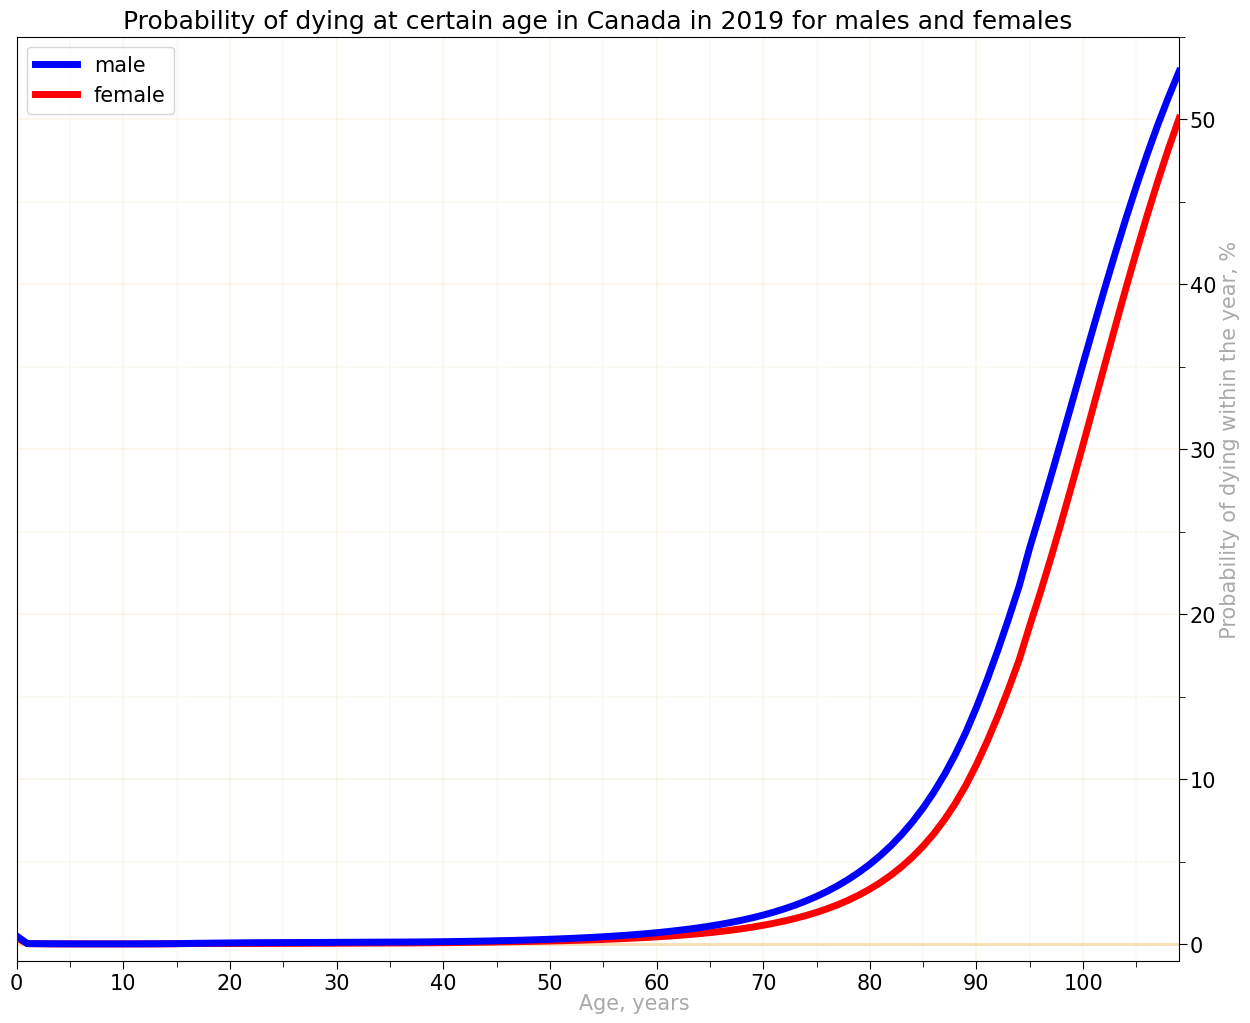

In [23]:
def create_chart(
        df, lang='en', dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)  # Minor ticks are shorter
    plt.xticks(fontsize=15)  # font size for tick labels
    plt.yticks(fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 55
    plt.xlim(0, 109)
    plt.ylim(-1, 55)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("          Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "                  Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=3)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -nolang' if lang=='nolang' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'male'  : DisplayedGroup(en_name="male",    ru_name="мужчины", nolang_name="♂", color='blue',      style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", nolang_name="∑", color='lightgrey', style='-', width=5, alpha=1),
    'female': DisplayedGroup(en_name="female",  ru_name="женщины", nolang_name="♀", color='red',       style='-', width=5, alpha=1)
}

for lang in LANGS:
    create_chart(df.T.loc[['male', 'female']],
                 dd_display=dd_display, lang=lang,
                 title_en=f"Probability of dying at certain age in Canada in {YEAR} for males and females",  # , overall statistics for males and females
                 title_ru=f"Вероятность смерти в определённом возрасте в Канаде в {YEAR} для мужчин и женщин",
                 file_name=f"Probability of Dying at Certain Age in Canada in {YEAR}")

Average mortality rate at the interval 21–30 years (incl.), %:   ♂: 0.087, ♀: 0.037
Average life expectancy, if the mortality rate was the same as at the plateau, years:   ♂: 1150, ♀: 2670


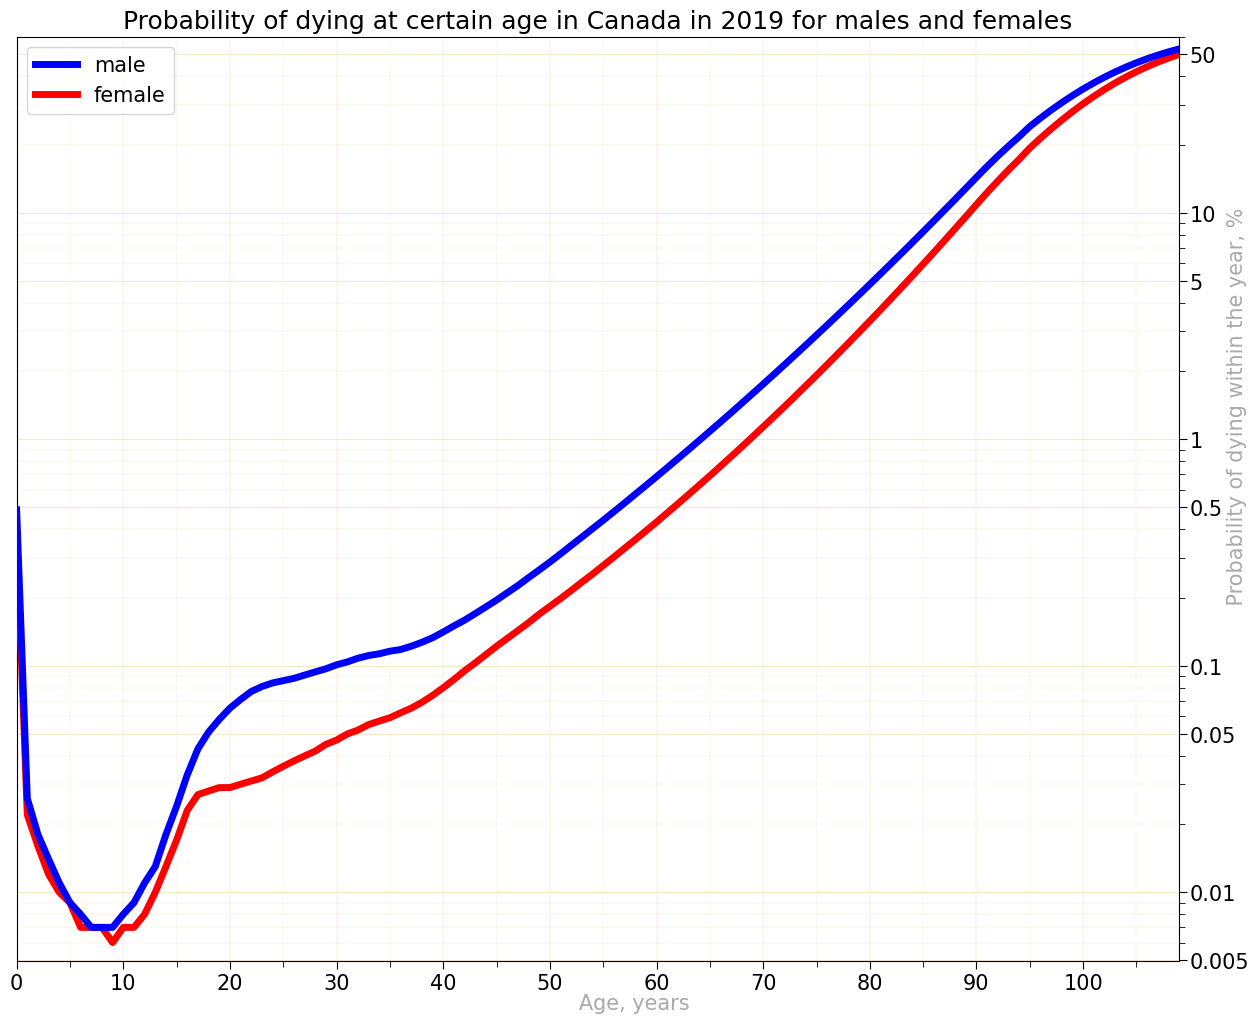

In [24]:
def create_chart_log(
        df, lang='en', dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика",
        plateau_years = slice(21, 30), show_plateau_lines=False,
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    # ax.yaxis.set_major_locator(ticker.LogLocator())
    # ax.yaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.005, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # for y_milestone in [0.1, 1, 10]:
    #     plt.axhline(y=y_milestone, color='wheat', linewidth=0.5)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("           Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "                            Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=-16)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    # Calculate and show statistics about "plateau" (from 21 to 30 years, including endpoints)
    plateau_mortality_male   = df.loc['male', plateau_years].mean()
    plateau_mortality_female = df.loc['female', plateau_years].mean()
    print(f"Average mortality rate at the interval {plateau_years.start}–{plateau_years.stop} years (incl.), %:   ♂: {plateau_mortality_male:.3f}, ♀: {plateau_mortality_female:.3f}")
    le_average_plateau_male   = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_male)
    le_average_plateau_female = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_female)
    print(f"Average life expectancy, if the mortality rate was the same as at the plateau, years:   ♂: {round(le_average_plateau_male, -1)}, ♀: {round(le_average_plateau_female, -1)}")
    
    if show_plateau_lines:  # show plateaux visually 
        for y_plateau in [plateau_mortality_male, plateau_mortality_female]:
             plt.hlines(y_plateau, plateau_years.start-5, plateau_years.stop+5, color='lime', linewidth=2, alpha=0.5)
    
    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -nolang' if lang=='nolang' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'male'  : DisplayedGroup(en_name="male",    ru_name="мужчины", nolang_name="♂", color='blue',      style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", nolang_name="∑", color='lightgrey', style='-', width=5, alpha=1),
    'female': DisplayedGroup(en_name="female",  ru_name="женщины", nolang_name="♀", color='red',       style='-', width=5, alpha=1)
}

for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
                 dd_display=dd_display, lang=lang,
                 title_en=f"Probability of dying at certain age in Canada in {YEAR} for males and females",  # , overall statistics for males and females
                 title_ru=f"Вероятность смерти в определённом возрасте в Канаде в {YEAR} для мужчин и женщин",
                 file_name=f"Probability of Dying at Certain Age in Canada in {YEAR} -log")

<br>
<br>

In [26]:
# Functions that I tried to use for approximations of a perido 40-90 years,
# where Gompertz–Makeham law of mortality takes place, but the result turned out unsatisfactory.
## Gompertz function with permanent Makeham component:
# def gompertz_makeham(age, amplitude, coef, external_mortality):
#     return amplitude * np.exp(coef * age) + makeham_component  # makeham_component - permanent external mortality

## simple Gompertz function
# def gompertz(age, amplitude, coef):
#     return amplitude * np.exp(coef * age)

# segment of ages (including endpoints) where aproximation is searched
# range_start = 40
# range_end = 90

# Lines of code that have to be inserted into the chart creation function
# to laucn approximation.
## Approximate data for segment where Gompertz–Makeham law of mortality takes place
# x_originals = np.linspace(range_start, range_end, range_end-range_start+1)
# y_originals = df.loc[group, x_originals].values / 100

# for group in ['male', 'female']:
#     coefs, _ = curve_fit(gompertz_makeham, x_originals, y_originals, p0=[1e-6, 0.10, 0.0005], maxfev = 100_000)
#     y_approximated = gompertz_makeham(x_originals, *coefs) * 100
#     plt.plot(x_originals, y_approximated, color='orange', linewidth=10, alpha=0.5, zorder=101)

In [27]:
# play beep to denote completion of the program
import IPython.display as ipd
import numpy as np

# manually generated sound
t = 1  # time is seconds
beep = np.sin(2*np.pi*400*np.arange(10000*t)/10000)
ipd.Audio(beep, rate=10000, autoplay=True)